In [16]:
#  for downloading the dataset, you can use the kagglehub library, which provides a interface to download datasets from Kaggle. Here's how you can do it:
# import kagglehub

# path = kagglehub.dataset_download(
#     "cjinny/mrnet-v1",
#     output_dir="/Users/yaseenahmed/Documents/ML Project/MRNet-v1", # use youre own path here for where you want to save the dataset guys.
#     force_download=True   # important since folder might exist partially
# )

# print("Downloaded to:", path)

In [17]:
# import os

# DATA_ROOT = "/Users/yaseenahmed/Documents/ML Project/MRNet-v1/MRNet-v1.0" 
# USe your actual path to the dataset here guys.

# print("Exists:", os.path.exists(DATA_ROOT))
# print("Contents:", os.listdir(DATA_ROOT))

In [18]:
# pip install timm scikit-learn matplotlib seaborn pandas tqdm pillow torchvision

# run the above cell to install the required libraries.

In [2]:
import os
import glob
import math
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms as T

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

import timm

In [20]:
from torch.utils.tensorboard import SummaryWriter
writer = SummaryWriter("runs/mrnet_experiment")

In [5]:
# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Paths
# -----------------------------
DATA_ROOT = "/Users/yaseenahmed/Documents/ML project/MRNet-v1/MRNet-v1.0"      # use your actual path to the dataset here
OOD_ROOT = "/Users/yaseenahmed/Documents/ML project/OOD_images"     # use your actual path to the OOD images here( you can create a folder and put some random images in it for testing).

# -----------------------------
# Basic settings
# -----------------------------
PLANE = "coronal"  # can be 'sagittal', 'coronal', or 'axial'
IMG_SIZE = 224
BATCH_SIZE = 2
NUM_EPOCHS = 20
LEARNING_RATE = 2e-5
NUM_WORKERS = 0
NUM_SLICES = 4       # use 3 evenly spaced slices per MRI volume
THRESHOLD = 0.45

In [8]:
# device configuration
import torch

if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
else:
    DEVICE = torch.device("cpu")

print("Using device:", DEVICE)

BATCH_SIZE = 4
NUM_WORKERS = 0

Using device: mps


In [7]:
def load_labels(data_root, split):
    """
    Loads the three binary labels:
    1. abnormal
    2. acl
    3. meniscus

    Returns:
        dict -> {exam_id: [abnormal, acl, meniscus]}
    """
    abnormal_path = os.path.join(data_root, f"{split}-abnormal.csv")
    acl_path = os.path.join(data_root, f"{split}-acl.csv")
    meniscus_path = os.path.join(data_root, f"{split}-meniscus.csv")

    abnormal_df = pd.read_csv(abnormal_path, header=None, names=["id", "abnormal"])
    acl_df = pd.read_csv(acl_path, header=None, names=["id", "acl"])
    meniscus_df = pd.read_csv(meniscus_path, header=None, names=["id", "meniscus"])

    merged_df = abnormal_df.merge(acl_df, on="id").merge(meniscus_df, on="id")

    labels = {}
    for _, row in merged_df.iterrows():
        exam_id = f"{int(row['id']):04d}"
        labels[exam_id] = [
            float(row["abnormal"]),
            float(row["acl"]),
            float(row["meniscus"])
        ]

    return labels

In [24]:
# Training-time augmentation
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# Validation / test transform
valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

In [25]:
class MRNetDataset(Dataset):
    def __init__(self, data_root, split="train", plane="sagittal", num_slices=5, transform=None):
        """
        A PyTorch Dataset for MRNet.

        Args:
            data_root   : root folder of MRNet
            split       : 'train' or 'valid'
            plane       : 'sagittal', 'coronal', or 'axial'
            num_slices  : number of evenly spaced slices to sample from volume
            transform   : torchvision transform to apply to each slice
        """
        self.data_root = data_root
        self.split = split
        self.plane = plane
        self.num_slices = num_slices
        self.transform = transform

        self.labels = load_labels(data_root, split)
        self.exam_ids = sorted(list(self.labels.keys()))
        self.volume_dir = os.path.join(data_root, split, plane)

    def __len__(self):
        return len(self.exam_ids)

    def normalize_slice(self, img):
        """
        Normalize a single MRI slice to range [0, 255]
        so it can be converted to a PIL image.
        """
        img = img.astype(np.float32)
        img_min = img.min()
        img_max = img.max()

        if img_max - img_min > 1e-8:
            img = (img - img_min) / (img_max - img_min)
        else:
            img = np.zeros_like(img, dtype=np.float32)

        img = (img * 255.0).clip(0, 255).astype(np.uint8)
        return img

    def get_slice_indices(self, num_total_slices):
        """
        Returns evenly spaced slice indices.
        Example: for 5 slices, picks slices spread across the full volume.
        """
        if self.num_slices >= num_total_slices:
            return np.arange(num_total_slices)

        return np.linspace(0, num_total_slices - 1, self.num_slices, dtype=int)

    def __getitem__(self, idx):
        exam_id = self.exam_ids[idx]
        volume_path = os.path.join(self.volume_dir, f"{exam_id}.npy")

        # Load MRI volume of shape (num_slices, H, W)
        volume = np.load(volume_path)

        # Select multiple evenly spaced slices
        slice_indices = self.get_slice_indices(volume.shape[0])

        slice_tensors = []
        for s_idx in slice_indices:
            img = volume[s_idx]
            img = self.normalize_slice(img)

            # Convert grayscale to RGB by duplicating channel
            pil_img = Image.fromarray(img).convert("RGB")

            if self.transform:
                pil_img = self.transform(pil_img)

            slice_tensors.append(pil_img)

        # Shape after stacking: (num_slices, 3, H, W)
        slice_tensors = torch.stack(slice_tensors, dim=0)

        # Multi-label target
        label = torch.tensor(self.labels[exam_id], dtype=torch.float32)

        return slice_tensors, label, exam_id

In [26]:
train_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="train",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=train_transform
)

valid_dataset = MRNetDataset(
    data_root=DATA_ROOT,
    split="valid",
    plane=PLANE,
    num_slices=NUM_SLICES,
    transform=valid_transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS
)

print("Train samples:", len(train_dataset))
print("Valid samples:", len(valid_dataset))

Train samples: 1130
Valid samples: 120


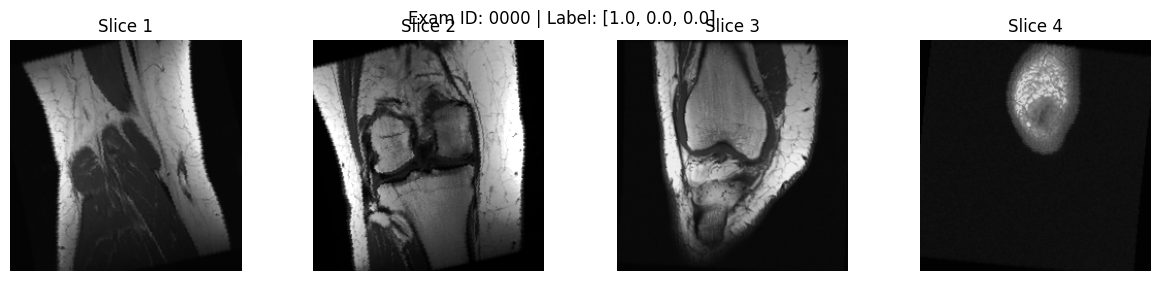

In [27]:
def denormalize_image(tensor_img):
    """
    Converts a normalized tensor image back to displayable format.
    """
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = tensor_img.cpu() * std + mean
    img = img.clamp(0, 1)
    return img.permute(1, 2, 0).numpy()

slice_stack, label, exam_id = train_dataset[0]

plt.figure(figsize=(15, 3))
for i in range(min(NUM_SLICES, 5)):
    plt.subplot(1, min(NUM_SLICES, 5), i + 1)
    plt.imshow(denormalize_image(slice_stack[i]))
    plt.title(f"Slice {i+1}")
    plt.axis("off")

plt.suptitle(f"Exam ID: {exam_id} | Label: {label.tolist()}")
plt.show()

In [28]:
def compute_pos_weights(dataset):
    """
    Computes positive class weights for BCEWithLogitsLoss.
    pos_weight = negatives / positives
    """
    all_labels = []

    for i in range(len(dataset)):
        _, label, _ = dataset[i]
        all_labels.append(label.numpy())

    all_labels = np.array(all_labels)
    positives = all_labels.sum(axis=0)
    negatives = len(all_labels) - positives

    pos_weight = negatives / (positives + 1e-8)
    return torch.tensor(pos_weight, dtype=torch.float32)

pos_weights = compute_pos_weights(train_dataset).to(DEVICE)
print("Positive class weights:", pos_weights)

Positive class weights: tensor([0.2377, 4.4327, 1.8463], device='mps:0')
